In [1]:
# ================================================================== PRESSURE STATS NOTEBOOK - cell 1: load the exported tables and check them
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

INPUT_DIR = Path("C:/Users/user/Desktop/Football_cv_project/football-pipeline (1)/project/new/press/buildup_output/pressure_stats_input")
OUT_DIR = INPUT_DIR.parent.parent / "pressure_stats_output"      # tables, figures and the summary json of this notebook
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------------ settings and tables written by the analysis notebook
meta = json.load(open(INPUT_DIR / "meta.json"))
TEAM_NAMES = {int(k): v for k, v in meta["team_names"].items()}
ATTACKS_POS_X = {int(k): bool(v) for k, v in meta["team_attacks_positive_x"].items()}
FPS, PITCH_LENGTH, PITCH_WIDTH = meta["fps"], meta["pitch_length"], meta["pitch_width"]
P = meta["params"]

buildups = pd.read_parquet(INPUT_DIR / "buildups.parquet")
frames = pd.read_parquet(INPUT_DIR / "frames.parquet")
defenders = pd.read_parquet(INPUT_DIR / "defenders.parquet")
positions = pd.read_parquet(INPUT_DIR / "positions.parquet")
spells = pd.read_parquet(INPUT_DIR / "spells.parquet")
roster = pd.read_parquet(INPUT_DIR / "roster.parquet")

tn = lambda t: TEAM_NAMES[int(t)]
other = lambda t: 1 - int(t)

# ------------------------------------------------------------------ helpers used by the next cells
def wilson(k, n, z=1.96):
    """95% interval for a proportion k / n."""
    if n == 0:
        return (np.nan, np.nan)
    p = k / n; den = 1 + z ** 2 / n
    c = (p + z ** 2 / (2 * n)) / den
    h = z * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2)) / den
    return (c - h, c + h)

def bool_runs(mask, frames_):
    """Inclusive (start_i, end_i) index pairs of True runs; runs never span a jump in the frame numbers."""
    mask = np.asarray(mask, bool); frames_ = np.asarray(frames_)
    if len(mask) == 0:
        return []
    brk = np.r_[True, (np.diff(frames_) != 1) | (mask[1:] != mask[:-1])]
    starts = np.flatnonzero(brk); ends = np.r_[starts[1:] - 1, len(mask) - 1]
    return [(int(s), int(e)) for s, e in zip(starts, ends) if mask[s]]

def mmss(frame):
    s = int(frame / FPS); return f"{s // 60:02d}:{s % 60:02d}"

# ------------------------------------------------------------------ 1) columns the later cells rely on
REQUIRED = dict(
    buildups=["buildup_id", "spell_id", "team", "team_name", "start_frame", "end_frame", "duration_sec", "start_third", "start_reason", "outcome",
              "target_coverage", "ball_target_share", "pressed_any", "pressure_share", "max_pressers", "pressed_from_start", "pressed_at_end",
              "time_to_first_pressure_sec", "first_press_third", "first_press_channel"],
    frames=["frame_idx", "spell_id", "poss_team", "def_team", "src", "n_pressing", "n_near", "min_dist", "n_def_tracked", "under_pressure",
            "carrier_track_id", "x", "y", "x_att", "y_att", "third"],
    defenders=["frame_idx", "spell_id", "track_id", "dist", "closing", "is_press", "is_near"],
    positions=["frame_idx", "track_id", "team", "role", "x", "y"],
    spells=["spell_id", "team", "start_frame", "end_frame", "start_type", "duration_sec"],
    roster=["track_id", "team", "role", "name", "number", "position"],
)
tables = dict(buildups=buildups, frames=frames, defenders=defenders, positions=positions, spells=spells, roster=roster)
print("tables loaded:")
for name, df in tables.items():
    missing = [c for c in REQUIRED[name] if c not in df.columns]
    print(f"  {name:10s} {len(df):>10,} rows x {df.shape[1]:>2} cols   " + ("all required columns present" if not missing else f"MISSING: {missing}"))

# the defenders table has no team column: take it from the roster (and cross-check with the frame table)
defenders = defenders.merge(roster[["track_id", "team", "number", "position"]].rename(columns={"team": "def_team_roster"}), on="track_id", how="left")
chk = defenders.merge(frames[["frame_idx", "def_team"]], on="frame_idx", how="left")
print(f"\ndefender rows whose roster team differs from the frame's defending team: {(chk.def_team_roster != chk.def_team).mean() * 100:.2f}% (should be ~0)")

# ------------------------------------------------------------------ 2) what the data covers
print(f"\nsettings: {FPS} fps, pitch {PITCH_LENGTH:.0f} x {PITCH_WIDTH:.0f} m; teams {TEAM_NAMES}; attacks towards +x: {ATTACKS_POS_X}")
print(f"possession frames with a press target: {len(frames):,} = {len(frames) / FPS / 60:.1f} min of play (the half is {frames.frame_idx.max() / FPS / 60:.1f} min long)")

cov = frames.groupby("poss_team").agg(frames=("frame_idx", "size"), under_pressure_pct=("under_pressure", lambda s: s.mean() * 100),
                                      mean_pressers=("n_pressing", "mean"), defenders_tracked=("n_def_tracked", "mean"))
cov["minutes_with_ball"] = cov["frames"] / FPS / 60
cov.index = [f"{tn(t)} (has the ball)" for t in cov.index]
print("\nper team in possession:"); print(cov.round(2).to_string())

print("\nbuild-ups by team and outcome:")
print(buildups.groupby(["team_name", "outcome"]).size().unstack(fill_value=0).to_string())
print(f"\nframes where the target is the carrier / the ball: {frames.src.value_counts(normalize=True).mul(100).round(1).to_dict()}")
print(f"frames with fewer than 6 defenders tracked: {(frames.n_def_tracked < 6).mean() * 100:.1f}%")
print(f"possession spells: {len(spells)}; frame table spells missing from the spells table: {(~frames.spell_id.isin(spells.spell_id)).sum()}")
print(f"positions: {positions.frame_idx.nunique():,} frames, {positions.groupby('frame_idx').size().mean():.1f} tracked players per frame (incl. goalkeepers)")

tables loaded:
  buildups          181 rows x 31 cols   all required columns present
  frames         52,561 rows x 16 cols   all required columns present
  defenders     508,077 rows x  7 cols   all required columns present
  positions   1,060,375 rows x  6 cols   all required columns present
  spells            199 rows x  9 cols   all required columns present
  roster             22 rows x  6 cols   all required columns present

defender rows whose roster team differs from the frame's defending team: 0.00% (should be ~0)

settings: 25 fps, pitch 105 x 68 m; teams {0: 'ATM', 1: 'BAR'}; attacks towards +x: {0: False, 1: True}
possession frames with a press target: 52,561 = 35.0 min of play (the half is 46.7 min long)

per team in possession:
                    frames  under_pressure_pct  mean_pressers  defenders_tracked  minutes_with_ball
ATM (has the ball)   21470               29.29           0.37               9.50              14.31
BAR (has the ball)   31091               26.11 

BUILD-UPS per team (start in own or middle third, ends in success / loss / undecided); interval = 95% Wilson
team                            ATM            BAR
build-ups                        91             90
success                          13             46
lost                             52             25
undecided                        26             19
success of decided    20.0% (12-31)  64.8% (53-75)
success of all %               14.3           51.1
median duration s               5.9            4.8
start own third %              63.7           25.6
start middle third %           36.3           74.4
after turnover %               65.9           55.6
after restart %                31.9           22.2
recycled %                      2.2           22.2

PRESSURE FACED, share of possession time (95% interval from resampling possession spells)
team                                           ATM            BAR
minutes with the ball                         14.3           20.7
time 

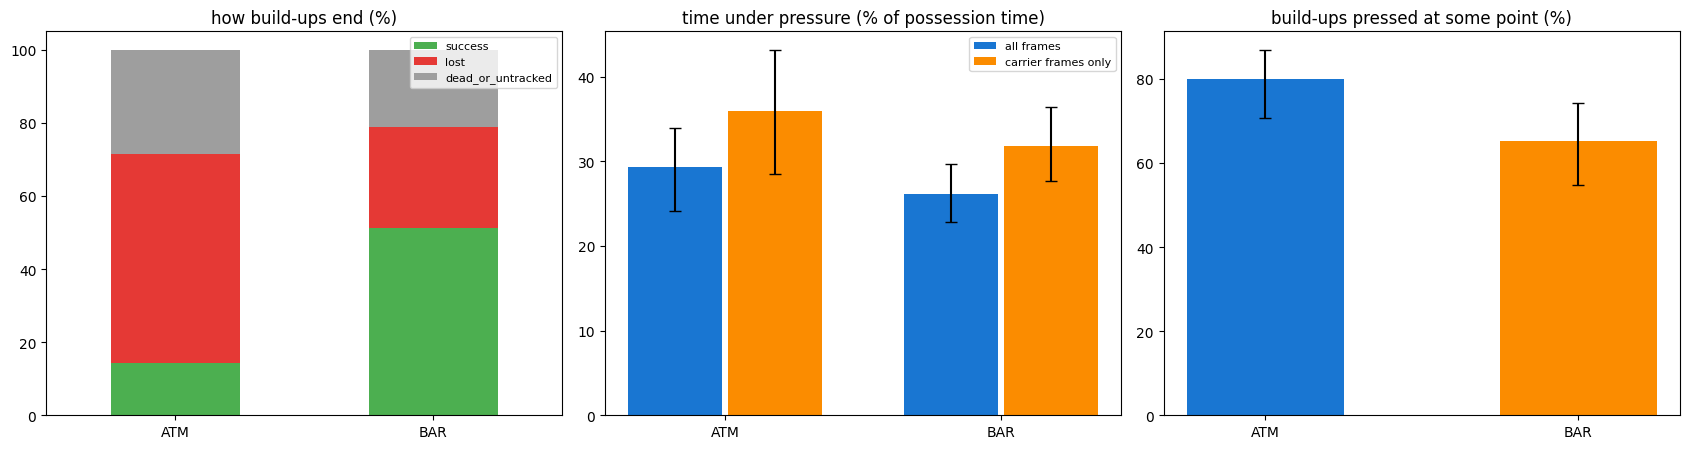


saved 3 tables + 1 figure to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\pressure_stats_output


In [2]:
# ================================================================== cell 2: build-ups and PRESSURE FACED (per team in possession)
N_BOOT = 2000
MIN_COVERAGE = 0.5          # pressure statistics use build-ups with a press target in at least this share of their frames

def boot_ratio(df, num, den, by="spell_id", n_boot=N_BOOT, seed=0):
    """Share = sum(num) / sum(den) with a 95% interval from resampling whole possession spells (frames inside a spell are not independent)."""
    g = df.groupby(by).agg(n=(num, "sum"), d=(den, "sum"))
    a = g[["n", "d"]].to_numpy(float); k = len(a)
    rng = np.random.default_rng(seed)
    s = a[rng.integers(0, k, (n_boot, k))].sum(axis=1)
    r = s[:, 0] / s[:, 1]
    return a[:, 0].sum() / a[:, 1].sum(), np.percentile(r, 2.5), np.percentile(r, 97.5)

def fmt(p, lo, hi, pct=True):
    return f"{p * 100:.1f}% ({lo * 100:.0f}-{hi * 100:.0f})" if pct else f"{p:.2f} ({lo:.2f}-{hi:.2f})"

fr = frames.copy()
fr["one"] = 1; fr["pressed"] = fr["under_pressure"].astype(int)
fr["pressed_multi"] = ((fr["n_pressing"] >= 2) & fr["under_pressure"]).astype(int)
bu = buildups.copy()

# ------------------------------------------------------------------ A) build-ups per team
rows = []
for t in (0, 1):
    b = bu[bu.team == t]; n = len(b)
    s_, l_ = int((b.outcome == "success").sum()), int((b.outcome == "lost").sum()); u_ = n - s_ - l_
    lo, hi = wilson(s_, s_ + l_)
    rows.append({"team": tn(t), "build-ups": n, "success": s_, "lost": l_, "undecided": u_,
                 "success of decided": f"{s_ / (s_ + l_) * 100:.1f}% ({lo * 100:.0f}-{hi * 100:.0f})",
                 "success of all %": round(s_ / n * 100, 1), "median duration s": round(b.duration_sec.median(), 1),
                 "start own third %": round((b.start_third == "own_third").mean() * 100, 1),
                 "start middle third %": round((b.start_third == "middle_third").mean() * 100, 1),
                 "after turnover %": round((b.start_reason == "turnover").mean() * 100, 1),
                 "after restart %": round((b.start_reason == "restart").mean() * 100, 1),
                 "recycled %": round((b.start_reason == "recycled_after_attack").mean() * 100, 1)})
tbl_buildups = pd.DataFrame(rows).set_index("team")
print("BUILD-UPS per team (start in own or middle third, ends in success / loss / undecided); interval = 95% Wilson")
print(tbl_buildups.T.to_string())

# ------------------------------------------------------------------ B) pressure faced, frame based (time under pressure)
rows = []
for t in (0, 1):
    f = fr[fr.poss_team == t]; fc = f[f.src == "carrier"]
    p, lo, hi = boot_ratio(f, "pressed", "one"); pc, loc_, hic = boot_ratio(fc, "pressed", "one")
    pm, lom, him = boot_ratio(f[f.pressed == 1], "pressed_multi", "one")
    rows.append({"team": tn(t), "minutes with the ball": round(len(f) / FPS / 60, 1),
                 "time under pressure": fmt(p, lo, hi), "... carrier frames only": fmt(pc, loc_, hic),
                 "pressed frames with 2+ pressers": fmt(pm, lom, him),
                 "mean pressers when pressed": round(f.loc[f.pressed == 1, "n_pressing"].mean(), 2),
                 "mean distance of nearest defender m": round(f.min_dist.mean(), 1)})
tbl_pressure_faced = pd.DataFrame(rows).set_index("team")
print("\nPRESSURE FACED, share of possession time (95% interval from resampling possession spells)")
print(tbl_pressure_faced.T.to_string())

# ------------------------------------------------------------------ C) pressure faced, build-up based
b = bu[bu.target_coverage >= MIN_COVERAGE].copy()
for c in ["pressed_any", "pressed_from_start", "pressed_at_end"]:
    b[c] = b[c].astype(bool)
rows = []
for t in (0, 1):
    x = b[b.team == t]; n = len(x)
    pa, pf_, pe = int(x.pressed_any.sum()), int(x.pressed_from_start.sum()), int(x.pressed_at_end.sum())
    w1, w2, w3 = wilson(pa, n), wilson(pf_, n), wilson(pe, n)
    ttp = x.loc[x.pressed_any, "time_to_first_pressure_sec"]
    rows.append({"team": tn(t), "build-ups used": n,
                 "pressed at some point": f"{pa / n * 100:.1f}% ({w1[0] * 100:.0f}-{w1[1] * 100:.0f})",
                 "pressed from the start (<=1 s)": f"{pf_ / n * 100:.1f}% ({w2[0] * 100:.0f}-{w2[1] * 100:.0f})",
                 "pressed in the last second": f"{pe / n * 100:.1f}% ({w3[0] * 100:.0f}-{w3[1] * 100:.0f})",
                 "median time to first pressure s": round(ttp.median(), 2), "75th percentile s": round(ttp.quantile(0.75), 2),
                 "mean share of build-up under pressure %": round(x.pressure_share.mean() * 100, 1),
                 "mean max pressers": round(x.max_pressers.mean(), 2)})
tbl_pressure_buildups = pd.DataFrame(rows).set_index("team")
print(f"\nPRESSURE FACED, per build-up ({len(b)} of {len(bu)} build-ups have a press target in at least {MIN_COVERAGE:.0%} of their frames)")
print(tbl_pressure_buildups.T.to_string())

# ------------------------------------------------------------------ figure + saved tables
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
cols = {"success": "#4CAF50", "lost": "#E53935", "dead_or_untracked": "#9E9E9E"}
oc = bu.groupby(["team_name", "outcome"]).size().unstack(fill_value=0).reindex(columns=list(cols)).fillna(0)
(oc.div(oc.sum(axis=1), axis=0) * 100).plot.bar(stacked=True, ax=ax[0], color=[cols[c] for c in oc.columns], rot=0)
ax[0].set_title("how build-ups end (%)"); ax[0].set_xlabel(""); ax[0].legend(fontsize=8)
for i, t in enumerate((0, 1)):
    f = fr[fr.poss_team == t]
    for j, (sub, lab, col) in enumerate([(f, "all frames", "#1976D2"), (f[f.src == "carrier"], "carrier frames only", "#FB8C00")]):
        p, lo, hi = boot_ratio(sub, "pressed", "one")
        ax[1].bar(i + (j - 0.5) * 0.36, p * 100, 0.34, yerr=[[(p - lo) * 100], [(hi - p) * 100]], color=col, capsize=4, label=lab if i == 0 else None)
ax[1].set_xticks([0, 1]); ax[1].set_xticklabels([tn(0), tn(1)]); ax[1].set_title("time under pressure (% of possession time)"); ax[1].legend(fontsize=8)
for i, t in enumerate((0, 1)):
    x = b[b.team == t]; n = len(x); pa = int(x.pressed_any.sum()); lo, hi = wilson(pa, n)
    ax[2].bar(i, pa / n * 100, 0.5, yerr=[[(pa / n - lo) * 100], [(hi - pa / n) * 100]], color=["#1976D2", "#FB8C00"][i], capsize=4)
ax[2].set_xticks([0, 1]); ax[2].set_xticklabels([tn(0), tn(1)]); ax[2].set_title("build-ups pressed at some point (%)")
plt.tight_layout(); plt.savefig(OUT_DIR / "fig_2_buildups_and_pressure_faced.png", dpi=130); plt.show()

for name, tbl in [("tbl_buildups_team", tbl_buildups), ("tbl_pressure_faced_frames", tbl_pressure_faced), ("tbl_pressure_faced_buildups", tbl_pressure_buildups)]:
    tbl.to_csv(OUT_DIR / f"{name}.csv")
print("\nsaved 3 tables + 1 figure to", OUT_DIR)

498 pressure episodes (unbroken runs of sustained pressure inside a possession spell)

PRESSING DELIVERED per team (95% intervals from resampling possession spells)
pressing team                                                           ATM                  BAR
minutes defending                                                      20.7                 14.3
time pressing                                                 26.1% (23-30)        29.3% (24-34)
... carrier frames only                                       31.8% (28-36)        35.9% (29-43)
episodes                                                                285                  213
episodes per 10 min                                     137.5 (121.7-153.5)  148.8 (125.4-170.2)
median duration s                                                      0.92                 0.92
mean duration s                                                        1.14                 1.18
75th pct duration s                                        

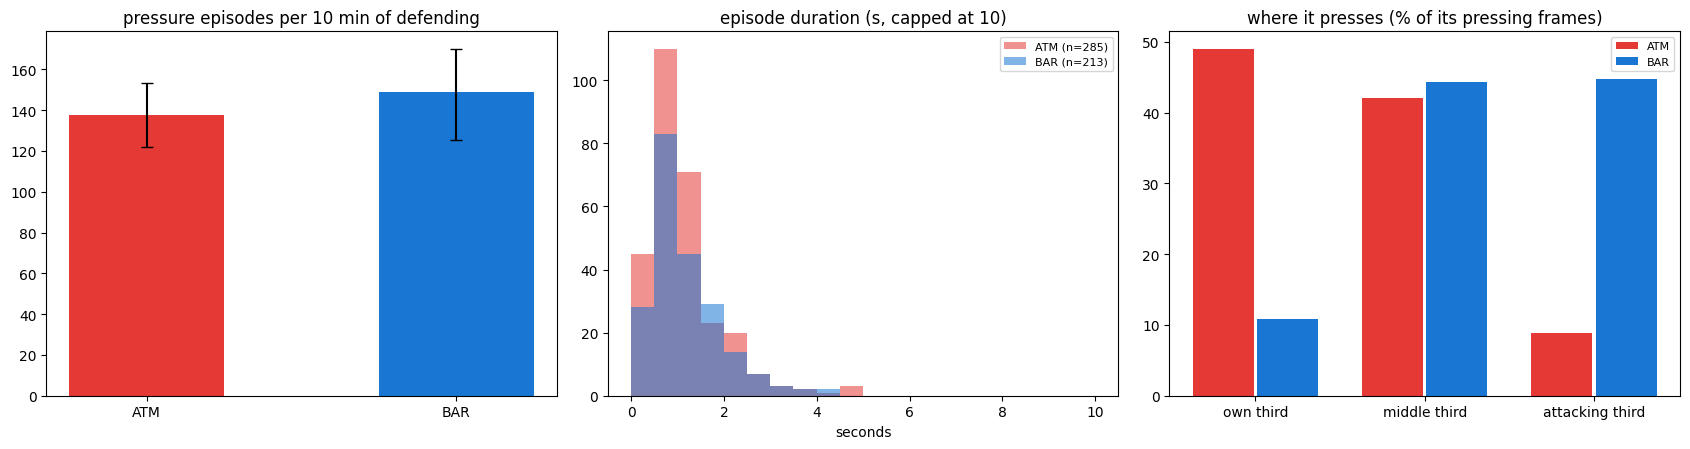


saved press_episodes.csv, 2 tables and 1 figure to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\pressure_stats_output


In [3]:
# ================================================================== cell 3: PRESSING DELIVERED (per team out of possession)
# "ATM pressing" = frames where BAR has the ball and ATM presses the ball carrier. Heights are measured from the PRESSING team's own goal.
COUNTERPRESS_SEC = 5.0

fr = frames.sort_values("frame_idx").copy()
fr["one"] = 1; fr["pressed"] = fr["under_pressure"].astype(int)
fr["press_height_m"] = PITCH_LENGTH - fr["x_att"]        # x_att is in the ball team's frame: 105 - x_att = distance of the ball from the pressing team's own goal
fr["press_third"] = pd.cut(fr["press_height_m"], [-np.inf, PITCH_LENGTH / 3, 2 * PITCH_LENGTH / 3, np.inf],
                           labels=["own third", "middle third", "attacking third"], right=False).astype(object)
sp = spells.set_index("spell_id")

# ------------------------------------------------------------------ pressure episodes = unbroken runs of "under pressure" inside one possession spell
eps = []
for sid, g in fr.groupby("spell_id", sort=False):
    f = g.frame_idx.to_numpy(); up = g.under_pressure.to_numpy(bool)
    for s, e in bool_runs(up, f):
        seg = g.iloc[s:e + 1]
        since = (f[s] - sp.loc[sid, "start_frame"]) / FPS
        eps.append(dict(spell_id=sid, press_team=int(g.def_team.iloc[0]), pressed_team=int(g.poss_team.iloc[0]),
                        start_frame=int(f[s]), end_frame=int(f[e]), start_time=mmss(f[s]), duration_sec=(e - s + 1) / FPS,
                        max_pressers=int(seg.n_pressing.max()), mean_pressers=float(seg.n_pressing.mean()), min_dist_m=float(seg.min_dist.min()),
                        carrier_share=float((seg.src == "carrier").mean()),
                        press_height_start_m=float(seg.press_height_m.iloc[0]), press_third=seg.press_third.iloc[0],
                        since_spell_start_sec=float(since), counterpress=bool(sp.loc[sid, "start_type"] == "turnover" and since <= COUNTERPRESS_SEC)))
episodes = pd.DataFrame(eps)
print(f"{len(episodes)} pressure episodes (unbroken runs of sustained pressure inside a possession spell)\n")

# ------------------------------------------------------------------ A) team table
rows = []
for t in (0, 1):
    f = fr[fr.def_team == t]; e = episodes[episodes.press_team == t]
    minutes = len(f) / FPS / 60
    p, lo, hi = boot_ratio(f, "pressed", "one"); pc, loc_, hic = boot_ratio(f[f.src == "carrier"], "pressed", "one")
    per = f.groupby("spell_id").agg(frames=("one", "sum")).join(e.groupby("spell_id").size().rename("n_ep")).fillna(0)
    per["n_ep_scaled"] = per["n_ep"]; per["frames_scaled"] = per["frames"] / (FPS * 600)         # episodes per 10 minutes
    r, rlo, rhi = boot_ratio(per.reset_index(), "n_ep", "frames_scaled", by="spell_id")
    rows.append({"pressing team": tn(t), "minutes defending": round(minutes, 1),
                 "time pressing": fmt(p, lo, hi), "... carrier frames only": fmt(pc, loc_, hic),
                 "episodes": len(e), "episodes per 10 min": f"{r:.1f} ({rlo:.1f}-{rhi:.1f})",
                 "median duration s": round(e.duration_sec.median(), 2), "mean duration s": round(e.duration_sec.mean(), 2),
                 "75th pct duration s": round(e.duration_sec.quantile(0.75), 2), "longest s": round(e.duration_sec.max(), 1),
                 "episodes with 2+ pressers %": round((e.max_pressers >= 2).mean() * 100, 1),
                 "mean pressers per episode": round(e.mean_pressers.mean(), 2),
                 "counter-press episodes % (<=5 s after losing the ball)": round(e.counterpress.mean() * 100, 1),
                 "mean pressing height m (from own goal)": round(e.press_height_start_m.mean(), 1)})
tbl_pressing = pd.DataFrame(rows).set_index("pressing team")
print("PRESSING DELIVERED per team (95% intervals from resampling possession spells)")
print(tbl_pressing.T.to_string())

# ------------------------------------------------------------------ B) where the pressing happens: how often does the team press when the ball is in each third?
rows = []
for t in (0, 1):
    f = fr[(fr.def_team == t) & fr.press_third.notna()]
    for third in ["own third", "middle third", "attacking third"]:
        s_ = f[f.press_third == third]
        if len(s_) < 50:
            rows.append({"pressing team": tn(t), "ball is in the pressing team's": third, "minutes defending there": round(len(s_) / FPS / 60, 1), "pressing rate": "n/a"}); continue
        p, lo, hi = boot_ratio(s_, "pressed", "one")
        rows.append({"pressing team": tn(t), "ball is in the pressing team's": third, "minutes defending there": round(len(s_) / FPS / 60, 1),
                     "pressing rate": fmt(p, lo, hi), "share of all its pressing frames %": round(s_.pressed.sum() / f.pressed.sum() * 100, 1)})
tbl_press_height = pd.DataFrame(rows)
print("\nWHERE: pressing rate by the third the ball is in (measured from the pressing team's own goal)")
print(tbl_press_height.to_string(index=False))

# ------------------------------------------------------------------ figure + saved tables
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6)); col = ["#E53935", "#1976D2"]
for i, t in enumerate((0, 1)):
    f = fr[fr.def_team == t]; e = episodes[episodes.press_team == t]
    per = f.groupby("spell_id").agg(frames=("one", "sum")).join(e.groupby("spell_id").size().rename("n_ep")).fillna(0)
    per["frames_scaled"] = per["frames"] / (FPS * 600)
    r, lo, hi = boot_ratio(per.reset_index(), "n_ep", "frames_scaled", by="spell_id")
    ax[0].bar(i, r, 0.5, yerr=[[r - lo], [hi - r]], color=col[i], capsize=4)
    ax[1].hist(e.duration_sec.clip(upper=10), bins=np.arange(0, 10.5, 0.5), alpha=0.55, color=col[i], label=f"{tn(t)} (n={len(e)})")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels([tn(0), tn(1)]); ax[0].set_title("pressure episodes per 10 min of defending")
ax[1].set_title("episode duration (s, capped at 10)"); ax[1].legend(fontsize=8); ax[1].set_xlabel("seconds")
order = ["own third", "middle third", "attacking third"]
for i, t in enumerate((0, 1)):
    f = fr[(fr.def_team == t) & (fr.pressed == 1) & fr.press_third.notna()]
    share = f.press_third.value_counts(normalize=True).reindex(order).fillna(0) * 100
    ax[2].bar(np.arange(3) + (i - 0.5) * 0.38, share.values, 0.36, color=col[i], label=tn(t))
ax[2].set_xticks(range(3)); ax[2].set_xticklabels(order); ax[2].set_title("where it presses (% of its pressing frames)"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT_DIR / "fig_3_pressing_delivered.png", dpi=130); plt.show()

episodes.to_csv(OUT_DIR / "press_episodes.csv", index=False)
tbl_pressing.to_csv(OUT_DIR / "tbl_pressing_delivered.csv"); tbl_press_height.to_csv(OUT_DIR / "tbl_press_height.csv", index=False)
print("\nsaved press_episodes.csv, 2 tables and 1 figure to", OUT_DIR)

EPISODE DEFINITION: how the counts change (the chosen definition is the 5th row unless you edit EP_* above)
                                                    episodes  ATM per 10 min  BAR per 10 min  median duration s  75th pct s  share >= 3 s %
definition                                                                                                                                 
raw runs of sustained pressure                           498           137.5           148.8               0.92        1.44             3.2
bridge gaps up to 0.5 s                                  371           101.3           112.5               1.16        1.92            11.1
bridge gaps up to 1 s                                    324            87.8            99.2               1.40        2.60            19.8
bridge gaps up to 2 s                                    259            69.5            80.3               2.28        4.04            37.1
stay while a defender is within 7 m, gaps <= 0.5 s  

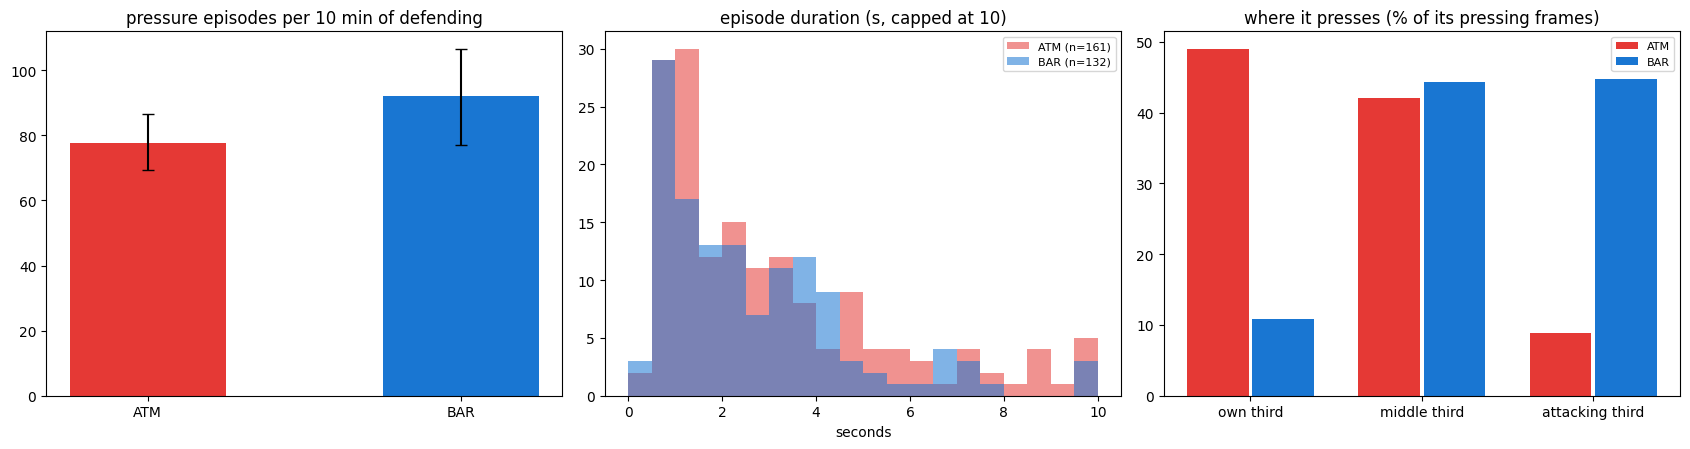


saved press_episodes.csv, 3 tables and 1 figure to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\pressure_stats_output


In [4]:
# ================================================================== cell 3: PRESSING DELIVERED (per team out of possession)
# "ATM pressing" = frames where BAR has the ball and ATM presses the ball carrier. Heights are measured from the PRESSING team's own goal.
COUNTERPRESS_SEC = 5.0

fr = frames.sort_values("frame_idx").copy()
fr["one"] = 1; fr["pressed"] = fr["under_pressure"].astype(int)
fr["press_height_m"] = PITCH_LENGTH - fr["x_att"]        # x_att is in the ball team's frame: 105 - x_att = distance of the ball from the pressing team's own goal
fr["press_third"] = pd.cut(fr["press_height_m"], [-np.inf, PITCH_LENGTH / 3, 2 * PITCH_LENGTH / 3, np.inf],
                           labels=["own third", "middle third", "attacking third"], right=False).astype(object)
sp = spells.set_index("spell_id")

# ------------------------------------------------------------------ pressure episodes
# An episode STARTS when sustained pressure starts (the strict rule from the analysis notebook). It then CONTINUES while pressure holds or, with
# EP_STAY_NEAR, while a defender is still within NEAR_DIST_M of the pressed player, and short interruptions (<= EP_BRIDGE_SEC) are bridged.
# This is the same "strict to enter, relaxed to stay" idea used for the first event detector: it stops one real press from being cut into pieces.
EP_STAY_NEAR = True
EP_BRIDGE_SEC = 0.5
EP_MIN_SEC = 0.5
F = lambda sec: int(round(sec * FPS))

def build_episodes(stay_near=EP_STAY_NEAR, bridge_sec=EP_BRIDGE_SEC, min_sec=EP_MIN_SEC):
    bridge, min_f = F(bridge_sec), F(min_sec)
    out = []
    for sid, g in fr.groupby("spell_id", sort=False):
        f = g.frame_idx.to_numpy(); seed = g.under_pressure.to_numpy(bool)
        if not seed.any():
            continue
        stay = seed | (g.n_near.to_numpy() >= 1) if stay_near else seed.copy()
        stay = stay.copy()
        for s_, e_ in bool_runs(~stay, f):                       # bridge short interior gaps
            if s_ > 0 and e_ < len(f) - 1 and (e_ - s_ + 1) <= bridge:
                stay[s_:e_ + 1] = True
        since_base = sp.loc[sid, "start_frame"]
        for s_, e_ in bool_runs(stay, f):
            hit = np.flatnonzero(seed[s_:e_ + 1])
            if len(hit) == 0:
                continue
            a_ = s_ + hit[0]                                     # an episode starts at the first sustained-pressure frame
            if e_ - a_ + 1 < min_f:
                continue
            seg = g.iloc[a_:e_ + 1]; since = (f[a_] - since_base) / FPS
            out.append(dict(spell_id=sid, press_team=int(g.def_team.iloc[0]), pressed_team=int(g.poss_team.iloc[0]),
                            start_frame=int(f[a_]), end_frame=int(f[e_]), start_time=mmss(f[a_]), n_frames=int(e_ - a_ + 1), duration_sec=(e_ - a_ + 1) / FPS,
                            max_pressers=int(seg.n_pressing.max()), mean_pressers=float(seg.n_pressing.mean()), min_dist_m=float(seg.min_dist.min()),
                            pressure_frames_share=float(seg.under_pressure.mean()), carrier_share=float((seg.src == "carrier").mean()),
                            press_height_start_m=float(seg.press_height_m.iloc[0]), press_third=seg.press_third.iloc[0],
                            since_spell_start_sec=float(since), counterpress=bool(sp.loc[sid, "start_type"] == "turnover" and since <= COUNTERPRESS_SEC)))
    cols = ["spell_id", "press_team", "pressed_team", "start_frame", "end_frame", "start_time", "n_frames", "duration_sec", "max_pressers", "mean_pressers",
            "min_dist_m", "pressure_frames_share", "carrier_share", "press_height_start_m", "press_third", "since_spell_start_sec", "counterpress"]
    return pd.DataFrame(out, columns=cols)

# how sensitive are the episode counts to the definition? (point estimates)
mins = {t: (fr.def_team == t).sum() / FPS / 60 for t in (0, 1)}
rows = []
for label, sn, br, mn in [("raw runs of sustained pressure", False, 0.0, 0.4),
                          ("bridge gaps up to 0.5 s", False, 0.5, 0.5), ("bridge gaps up to 1 s", False, 1.0, 0.5), ("bridge gaps up to 2 s", False, 2.0, 0.5),
                          ("stay while a defender is within 7 m, gaps <= 0.5 s", True, 0.5, 0.5), ("stay while within 7 m, gaps <= 1 s", True, 1.0, 0.5)]:
    e = build_episodes(sn, br, mn)
    rows.append({"definition": label, "episodes": len(e),
                 f"{tn(0)} per 10 min": round((e.press_team == 0).sum() / mins[0] * 10, 1), f"{tn(1)} per 10 min": round((e.press_team == 1).sum() / mins[1] * 10, 1),
                 "median duration s": round(e.duration_sec.median(), 2), "75th pct s": round(e.duration_sec.quantile(0.75), 2),
                 "share >= 3 s %": round((e.duration_sec >= 3).mean() * 100, 1)})
tbl_episode_sensitivity = pd.DataFrame(rows).set_index("definition")
print("EPISODE DEFINITION: how the counts change (the chosen definition is the 5th row unless you edit EP_* above)")
print(tbl_episode_sensitivity.to_string())

episodes = build_episodes()
print(f"\nchosen definition: stay near = {EP_STAY_NEAR}, bridge = {EP_BRIDGE_SEC} s, minimum = {EP_MIN_SEC} s  ->  {len(episodes)} pressure episodes\n")

# ------------------------------------------------------------------ A) team table
rows = []
for t in (0, 1):
    f = fr[fr.def_team == t]; e = episodes[episodes.press_team == t]
    minutes = len(f) / FPS / 60
    p, lo, hi = boot_ratio(f, "pressed", "one"); pc, loc_, hic = boot_ratio(f[f.src == "carrier"], "pressed", "one")
    per = f.groupby("spell_id").agg(frames=("one", "sum")).join(e.groupby("spell_id").size().rename("n_ep")).fillna(0)
    per["n_ep_scaled"] = per["n_ep"]; per["frames_scaled"] = per["frames"] / (FPS * 600)         # episodes per 10 minutes
    r, rlo, rhi = boot_ratio(per.reset_index(), "n_ep", "frames_scaled", by="spell_id")
    rows.append({"pressing team": tn(t), "minutes defending": round(minutes, 1),
                 "time pressing": fmt(p, lo, hi), "... carrier frames only": fmt(pc, loc_, hic),
                 "episodes": len(e), "episodes per 10 min": f"{r:.1f} ({rlo:.1f}-{rhi:.1f})",
                 "median duration s": round(e.duration_sec.median(), 2), "mean duration s": round(e.duration_sec.mean(), 2),
                 "75th pct duration s": round(e.duration_sec.quantile(0.75), 2), "longest s": round(e.duration_sec.max(), 1),
                 "episodes with 2+ pressers %": round((e.max_pressers >= 2).mean() * 100, 1),
                 "mean pressers per episode": round(e.mean_pressers.mean(), 2),
                 "counter-press episodes % (<=5 s after losing the ball)": round(e.counterpress.mean() * 100, 1),
                 "mean pressing height m (from own goal)": round(e.press_height_start_m.mean(), 1)})
tbl_pressing = pd.DataFrame(rows).set_index("pressing team")
print("PRESSING DELIVERED per team (95% intervals from resampling possession spells)")
print(tbl_pressing.T.to_string())

# ------------------------------------------------------------------ B) where the pressing happens: how often does the team press when the ball is in each third?
rows = []
for t in (0, 1):
    f = fr[(fr.def_team == t) & fr.press_third.notna()]
    for third in ["own third", "middle third", "attacking third"]:
        s_ = f[f.press_third == third]
        if len(s_) < 50:
            rows.append({"pressing team": tn(t), "ball is in the pressing team's": third, "minutes defending there": round(len(s_) / FPS / 60, 1), "pressing rate": "n/a"}); continue
        p, lo, hi = boot_ratio(s_, "pressed", "one")
        rows.append({"pressing team": tn(t), "ball is in the pressing team's": third, "minutes defending there": round(len(s_) / FPS / 60, 1),
                     "pressing rate": fmt(p, lo, hi), "share of all its pressing frames %": round(s_.pressed.sum() / f.pressed.sum() * 100, 1)})
tbl_press_height = pd.DataFrame(rows)
print("\nWHERE: pressing rate by the third the ball is in (measured from the pressing team's own goal)")
print(tbl_press_height.to_string(index=False))

# ------------------------------------------------------------------ figure + saved tables
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6)); col = ["#E53935", "#1976D2"]
for i, t in enumerate((0, 1)):
    f = fr[fr.def_team == t]; e = episodes[episodes.press_team == t]
    per = f.groupby("spell_id").agg(frames=("one", "sum")).join(e.groupby("spell_id").size().rename("n_ep")).fillna(0)
    per["frames_scaled"] = per["frames"] / (FPS * 600)
    r, lo, hi = boot_ratio(per.reset_index(), "n_ep", "frames_scaled", by="spell_id")
    ax[0].bar(i, r, 0.5, yerr=[[r - lo], [hi - r]], color=col[i], capsize=4)
    ax[1].hist(e.duration_sec.clip(upper=10), bins=np.arange(0, 10.5, 0.5), alpha=0.55, color=col[i], label=f"{tn(t)} (n={len(e)})")
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels([tn(0), tn(1)]); ax[0].set_title("pressure episodes per 10 min of defending")
ax[1].set_title("episode duration (s, capped at 10)"); ax[1].legend(fontsize=8); ax[1].set_xlabel("seconds")
order = ["own third", "middle third", "attacking third"]
for i, t in enumerate((0, 1)):
    f = fr[(fr.def_team == t) & (fr.pressed == 1) & fr.press_third.notna()]
    share = f.press_third.value_counts(normalize=True).reindex(order).fillna(0) * 100
    ax[2].bar(np.arange(3) + (i - 0.5) * 0.38, share.values, 0.36, color=col[i], label=tn(t))
ax[2].set_xticks(range(3)); ax[2].set_xticklabels(order); ax[2].set_title("where it presses (% of its pressing frames)"); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT_DIR / "fig_3_pressing_delivered.png", dpi=130); plt.show()

episodes.to_csv(OUT_DIR / "press_episodes.csv", index=False)
tbl_pressing.to_csv(OUT_DIR / "tbl_pressing_delivered.csv"); tbl_press_height.to_csv(OUT_DIR / "tbl_press_height.csv", index=False)
tbl_episode_sensitivity.to_csv(OUT_DIR / "tbl_episode_sensitivity.csv")
print("\nsaved press_episodes.csv, 3 tables and 1 figure to", OUT_DIR)

WHERE (1): share of each team's pressing frames by pitch cell, % (rows: third of the pitch counted from the pressing team's own goal)
pressing team ball in pressing team's  left  centre  right
          ATM               own third  24.7    10.6   13.7
          ATM            middle third  10.5    14.9   16.6
          ATM         attacking third   4.0     2.5    2.4
          BAR               own third   6.7     2.1    2.1
          BAR            middle third  14.9     9.1   20.3
          BAR         attacking third  11.6    11.2   22.0

WHERE (2): pressing rate in each cell, % of the defending frames spent there (blank = fewer than 50 frames)
pressing team ball in pressing team's  left  centre  right  defending minutes in this third
          ATM               own third  46.0    39.7   28.6                              6.9
          ATM            middle third  23.9    23.8   22.4                              9.8
          ATM         attacking third  18.2     7.2   14.0          

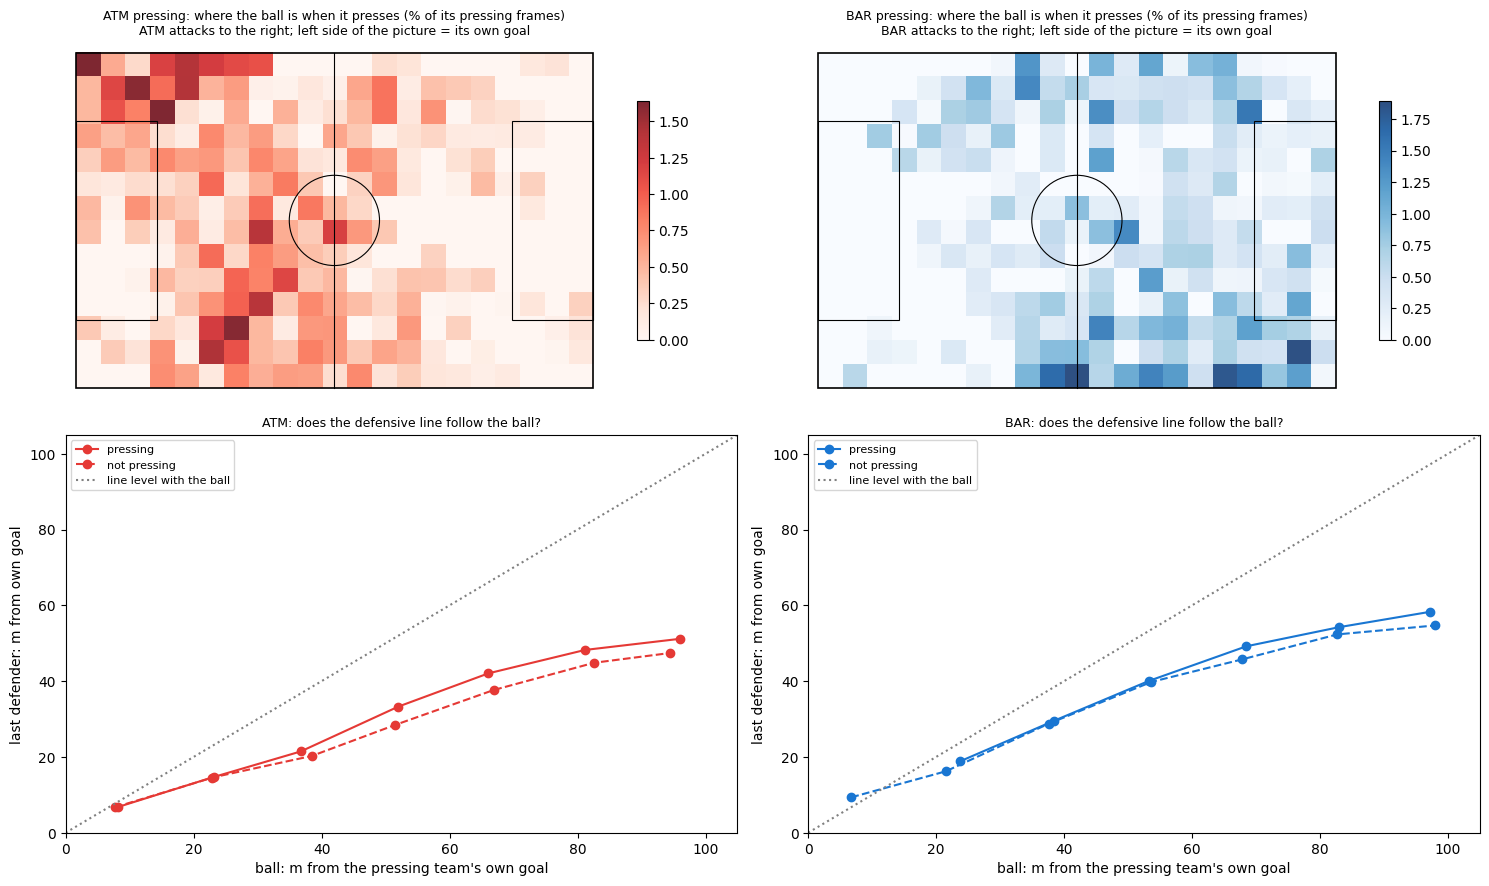


saved 3 tables and 1 figure to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\pressure_stats_output


In [5]:
# ================================================================== cell 4: WHERE and HOW the press happens (zone x side, and the defensive shape while pressing)
# needs cell 3 (fr with press_height_m / press_third, boot_ratio, fmt). Everything is seen from the PRESSING team's own attacking direction.
SIDE_NAMES = ["left", "centre", "right"]
THIRD_ORDER = ["own third", "middle third", "attacking third"]
MIN_TRACKED_FOR_SHAPE = 8      # shape statistics only use frames where at least this many of the defending team's outfield players are tracked
MIN_FRAMES_CELL = 50           # a pitch cell with fewer defending frames than this is not reported

fr4 = fr.copy()
fr4["x_p"] = fr4["press_height_m"]                           # metres from the pressing team's own goal
fr4["y_p"] = PITCH_WIDTH - fr4["y_att"]                      # side as seen from the pressing team (the ball team's frame turned by 180 degrees); low y = its left
fr4["side"] = pd.cut(fr4["y_p"], [-np.inf, PITCH_WIDTH / 3, 2 * PITCH_WIDTH / 3, np.inf], labels=SIDE_NAMES, right=False).astype(object)

# ------------------------------------------------------------------ A) zone x side: where does each team press, and how often when the ball is there?
rows_share, rows_rate = [], []
for t in (0, 1):
    f = fr4[(fr4.def_team == t) & fr4.press_third.notna() & fr4.side.notna()]
    cp = f[f.pressed == 1].groupby(["press_third", "side"]).size().unstack(fill_value=0).reindex(index=THIRD_ORDER, columns=SIDE_NAMES, fill_value=0)
    ca = f.groupby(["press_third", "side"]).size().unstack(fill_value=0).reindex(index=THIRD_ORDER, columns=SIDE_NAMES, fill_value=0)
    share = cp / cp.values.sum() * 100
    rate = (cp / ca.where(ca >= MIN_FRAMES_CELL)) * 100
    for th in THIRD_ORDER:
        rows_share.append({"pressing team": tn(t), "ball in pressing team's": th, **{s: round(share.loc[th, s], 1) for s in SIDE_NAMES}})
        rows_rate.append({"pressing team": tn(t), "ball in pressing team's": th, **{s: (round(rate.loc[th, s], 1) if pd.notna(rate.loc[th, s]) else np.nan) for s in SIDE_NAMES},
                          "defending minutes in this third": round(ca.loc[th].sum() / FPS / 60, 1)})
tbl_zone_share, tbl_zone_rate = pd.DataFrame(rows_share), pd.DataFrame(rows_rate)
print("WHERE (1): share of each team's pressing frames by pitch cell, % (rows: third of the pitch counted from the pressing team's own goal)")
print(tbl_zone_share.to_string(index=False))
print(f"\nWHERE (2): pressing rate in each cell, % of the defending frames spent there (blank = fewer than {MIN_FRAMES_CELL} frames)")
print(tbl_zone_rate.to_string(index=False))

# ------------------------------------------------------------------ B) defensive shape of the pressing team (last outfield defender, defensive line, depth, width)
pos = positions[positions.role == "player"].merge(frames[["frame_idx", "def_team"]], on="frame_idx")
pos = pos[pos.team == pos.def_team].copy()
own_goal_at_zero = pos["def_team"].map({t: ATTACKS_POS_X[t] for t in (0, 1)}).astype(bool)         # a team that attacks towards +x defends the goal at x = 0
pos["depth"] = np.where(own_goal_at_zero, pos["x"], PITCH_LENGTH - pos["x"]).clip(0, PITCH_LENGTH)   # distance from the team's own goal
g_ = pos.groupby("frame_idx")
shape = pd.DataFrame({"n_out": g_.size(), "last_def_m": g_["depth"].min(), "front_m": g_["depth"].max(), "y_min": g_["y"].min(), "y_max": g_["y"].max()})
shape["line3_m"] = pos.sort_values("depth").groupby("frame_idx").head(3).groupby("frame_idx")["depth"].mean()
shape["team_depth_m"] = shape["front_m"] - shape["last_def_m"]; shape["team_width_m"] = shape["y_max"] - shape["y_min"]
shape = shape[shape.n_out >= MIN_TRACKED_FOR_SHAPE]
fr4 = fr4.merge(shape.reset_index()[["frame_idx", "last_def_m", "line3_m", "team_depth_m", "team_width_m"]], on="frame_idx", how="left")
print(f"\nshape statistics use {fr4.last_def_m.notna().mean() * 100:.0f}% of the defending frames (at least {MIN_TRACKED_FOR_SHAPE} outfield players tracked)")

def boot_mean(df, col):
    d_ = df.dropna(subset=[col]).assign(v=lambda x: x[col], one=1)
    return boot_ratio(d_, "v", "one") if len(d_) > 30 else (np.nan, np.nan, np.nan)

METRICS = [("last_def_m", "last defender, m from own goal"), ("line3_m", "defensive line (3 deepest), m from own goal"),
           ("team_depth_m", "team depth (last to most advanced outfield player), m"), ("team_width_m", "team width, m")]
rows = []
for t in (0, 1):
    for state, sel in [("while pressing", fr4.pressed == 1), ("not pressing", fr4.pressed == 0)]:
        f = fr4[(fr4.def_team == t) & sel]
        row = {"team": tn(t), "state": state, "frames with shape data": int(f.last_def_m.notna().sum())}
        for c, lab in METRICS:
            m, lo, hi = boot_mean(f, c); row[lab] = f"{m:.1f} ({lo:.1f}-{hi:.1f})" if pd.notna(m) else "n/a"
        rows.append(row)
tbl_shape = pd.DataFrame(rows).set_index(["team", "state"])
print("\nHOW: defensive shape while the team defends (mean with 95% interval from resampling possession spells)")
print(tbl_shape.T.to_string())

# ------------------------------------------------------------------ figures: pressing map, and does the defensive line follow the ball?
def draw_pitch(ax):
    ax.add_patch(plt.Rectangle((0, 0), PITCH_LENGTH, PITCH_WIDTH, fill=False, color="black", lw=1.2)); ax.plot([PITCH_LENGTH / 2] * 2, [0, PITCH_WIDTH], "k", lw=0.8)
    ax.add_patch(plt.Circle((PITCH_LENGTH / 2, PITCH_WIDTH / 2), 9.15, fill=False, color="black", lw=0.8))
    for x0 in (0, PITCH_LENGTH - 16.5):
        ax.add_patch(plt.Rectangle((x0, (PITCH_WIDTH - 40.3) / 2), 16.5, 40.3, fill=False, color="black", lw=0.8))
    ax.set_xlim(-2, PITCH_LENGTH + 2); ax.set_ylim(PITCH_WIDTH + 2, -2); ax.set_aspect("equal"); ax.axis("off")

fig, ax = plt.subplots(2, 2, figsize=(15, 9))
for i, t in enumerate((0, 1)):
    f = fr4[(fr4.def_team == t) & (fr4.pressed == 1) & fr4.x_p.notna()]
    H_, xe, ye = np.histogram2d(f.x_p.clip(0, PITCH_LENGTH), f.y_p.clip(0, PITCH_WIDTH), bins=[21, 14], range=[[0, PITCH_LENGTH], [0, PITCH_WIDTH]])
    a = ax[0, i]; draw_pitch(a)
    im = a.imshow((H_.T / H_.sum() * 100), extent=[0, PITCH_LENGTH, PITCH_WIDTH, 0], cmap=["Reds", "Blues"][i], alpha=0.85, aspect="equal", zorder=0)
    a.set_title(f"{tn(t)} pressing: where the ball is when it presses (% of its pressing frames)\n{tn(t)} attacks to the right; left side of the picture = its own goal", fontsize=9)
    plt.colorbar(im, ax=a, shrink=0.6)
    b = ax[1, i]
    ok = fr4[(fr4.def_team == t) & fr4.last_def_m.notna() & fr4.press_height_m.notna()].copy()
    ok["bin"] = pd.cut(ok.press_height_m, np.arange(0, 106, 15))
    for state, sel, ls in [("pressing", ok.pressed == 1, "-"), ("not pressing", ok.pressed == 0, "--")]:
        m = ok[sel].groupby("bin", observed=True).agg(ball=("press_height_m", "mean"), line=("last_def_m", "mean"), n=("one", "size"))
        m = m[m.n >= 100]; b.plot(m.ball, m.line, ls, marker="o", color=["#E53935", "#1976D2"][i], label=state)
    b.plot([0, 105], [0, 105], ":", color="grey", label="line level with the ball"); b.set_xlim(0, 105); b.set_ylim(0, 105)
    b.set_xlabel("ball: m from the pressing team's own goal"); b.set_ylabel("last defender: m from own goal"); b.legend(fontsize=8)
    b.set_title(f"{tn(t)}: does the defensive line follow the ball?", fontsize=9)
plt.tight_layout(); plt.savefig(OUT_DIR / "fig_4_where_and_how.png", dpi=130); plt.show()

tbl_zone_share.to_csv(OUT_DIR / "tbl_zone_side_share.csv", index=False); tbl_zone_rate.to_csv(OUT_DIR / "tbl_zone_side_rate.csv", index=False)
tbl_shape.to_csv(OUT_DIR / "tbl_defensive_shape.csv")
print("\nsaved 3 tables and 1 figure to", OUT_DIR)

1,151 one-second moments from 145 build-ups; 115 lost the ball within 2 s; 40% of moments were pressed; lane data for 65% of moments

LOSS WITHIN 2 s, pressed in the last second vs not (difference in percentage points)
                                                   buildups  pressed_moments  pressed_loss_pct  unpressed_moments  unpressed_loss_pct  diff_pp         ci95
group                                                                                                                                                      
ATM                                                      77              273              17.9                289                10.7      7.2  0.5 to 14.0
BAR                                                      68              189              10.6                400                 3.8      6.8  1.3 to 13.5
BOTH                                                    145              462              14.9                689                 6.7      8.3  4.2 to 12.7
B

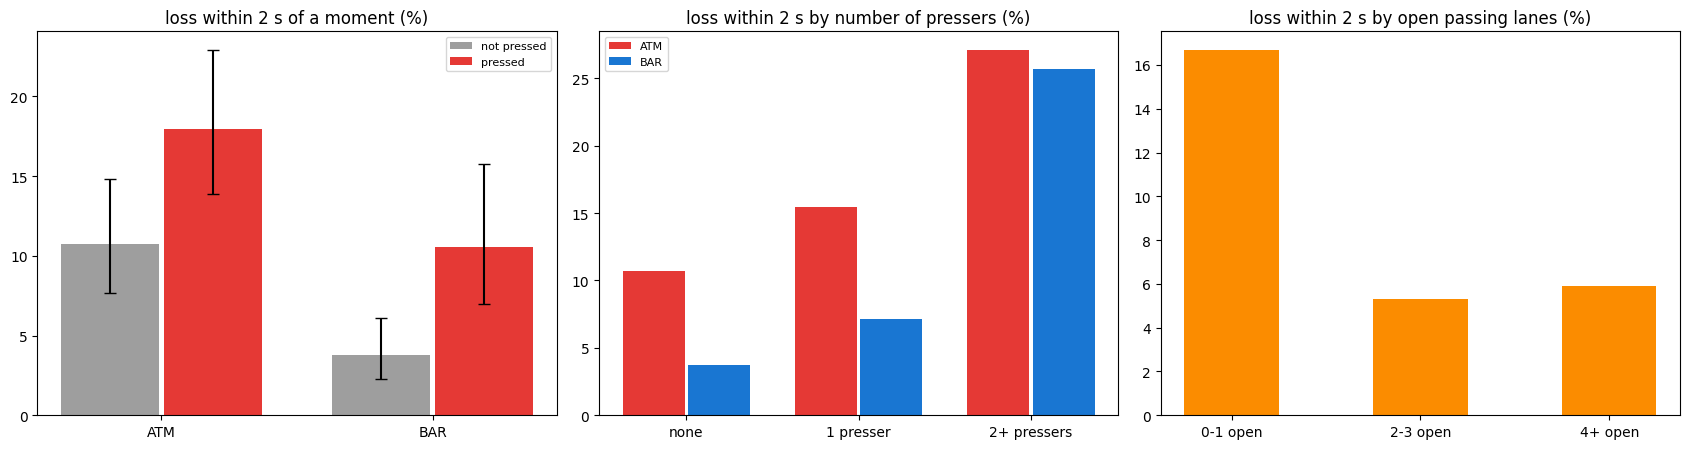


saved moments_for_effect.csv, 2 tables and 1 figure to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\pressure_stats_output


In [6]:
# ================================================================== cell 5: THE EFFECT - does being pressed make a team more likely to lose the ball?
# Moments: inside every build-up, one moment per second (after a grace period). For each moment we look BACK 1 s (was the team pressed? how many pressers?
# how many passing lanes were open?) and FORWARD 2 s (was the ball lost?). Moments are not independent, so intervals resample whole build-ups.
HAZ_GRACE_SEC, HAZ_LOOKBACK_SEC, HAZ_HORIZON_SEC, HAZ_STEP_SEC = 1.0, 1.0, 2.0, 1.0
N_BOOT_MODEL = 1000
LANE_BLOCK_M, LANE_CONTEST_M, LANE_MIN_M, LANE_MAX_M = 1.5, 3.0, 3.0, 45.0
G_, Lb, H_, S_ = [int(round(x * FPS)) for x in (HAZ_GRACE_SEC, HAZ_LOOKBACK_SEC, HAZ_HORIZON_SEC, HAZ_STEP_SEC)]

fr_i = frames.set_index("frame_idx").sort_index()
bu_ok = buildups[buildups.target_coverage >= MIN_COVERAGE].copy()

rows = []
for b in bu_ok.itertuples():
    t = int(b.start_frame) + G_ + Lb
    while t < b.end_frame:
        seg = fr_i.loc[t - Lb + 1:t]
        if len(seg):
            censored = (b.outcome in ("dead_or_untracked", "data_end")) and (b.end_frame <= t + H_)       # outcome unknown: do not count
            if not censored:
                up = seg.under_pressure.to_numpy(bool)
                last = seg.iloc[-1]
                rows.append(dict(buildup_id=b.buildup_id, team=int(b.team), frame=t, since_start_s=(t - b.start_frame) / FPS,
                                 pressed=int(up.any()), n_pressers=int(seg.loc[up, "n_pressing"].max()) if up.any() else 0,
                                 min_dist_m=float(seg.min_dist.min()), carrier_share=float((seg.src == "carrier").mean()),
                                 x_att=float(last.x_att) if pd.notna(last.x_att) else np.nan,
                                 carrier_id=last.carrier_track_id if pd.notna(last.carrier_track_id) else np.nan,
                                 loss_next=int(b.outcome == "lost" and b.end_frame <= t + H_)))
        t += S_
mom = pd.DataFrame(rows)

# ------------------------------------------------------------------ passing lanes at each moment (carrier -> each teammate; opponent within 3 m of the lane = contested)
need = set(mom.frame[mom.carrier_id.notna()])
pos_by_f = {k: g for k, g in positions[positions.frame_idx.isin(need)].groupby("frame_idx")}
def lane_counts(frame, carrier_id):
    g = pos_by_f.get(frame)
    if g is None or pd.isna(carrier_id):
        return (np.nan, np.nan, np.nan)
    car = g[g.track_id == carrier_id]
    if len(car) == 0:
        return (np.nan, np.nan, np.nan)
    car = car.iloc[0]; cxy = np.array([car.x, car.y])
    mates = g[(g.team == car.team) & (g.track_id != carrier_id) & (g.role == "player")]
    opps = g[g.team != car.team][["x", "y"]].to_numpy()
    o = c = bl = 0
    for r in mates.itertuples():
        ab = np.array([r.x, r.y]) - cxy; L = float(np.hypot(*ab))
        if L < LANE_MIN_M or L > LANE_MAX_M:
            continue
        dmin = np.inf
        if len(opps):
            tt = ((opps - cxy) @ ab) / (L * L); valid = (tt > 0.1) & (tt < 0.9)
            if valid.any():
                dmin = float(np.hypot(*(opps - (cxy + np.clip(tt, 0, 1)[:, None] * ab)).T)[valid].min())
        if dmin < LANE_BLOCK_M: bl += 1
        elif dmin < LANE_CONTEST_M: c += 1
        else: o += 1
    return (o, c, bl)
lc = [lane_counts(f, c) for f, c in zip(mom.frame, mom.carrier_id)]
mom[["lanes_open", "lanes_contested", "lanes_blocked"]] = pd.DataFrame(lc, index=mom.index)
print(f"{len(mom):,} one-second moments from {mom.buildup_id.nunique()} build-ups; {int(mom.loss_next.sum())} lost the ball within {HAZ_HORIZON_SEC:.0f} s; "
      f"{mom.pressed.mean() * 100:.0f}% of moments were pressed; lane data for {mom.lanes_open.notna().mean() * 100:.0f}% of moments\n")

# ------------------------------------------------------------------ A) simple comparison: loss within 2 s, pressed vs not (difference in points, interval from resampling build-ups)
def boot_diff(df, flag="pressed", y="loss_next", n_boot=2000, seed=1):
    c = df.groupby("buildup_id").apply(lambda g: pd.Series({"pn": (g[flag] == 1).sum(), "pl": ((g[flag] == 1) & (g[y] == 1)).sum(),
                                                            "un": (g[flag] == 0).sum(), "ul": ((g[flag] == 0) & (g[y] == 1)).sum()}), include_groups=False)
    a = c.to_numpy(float); tot = a.sum(axis=0); rate = lambda l, n: 100 * l / n if n else np.nan
    s = a[np.random.default_rng(seed).integers(0, len(a), (n_boot, len(a)))].sum(axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        d = 100 * (s[:, 1] / s[:, 0] - s[:, 3] / s[:, 2])
    lo, hi = np.nanpercentile(d, [2.5, 97.5])
    return dict(buildups=len(c), pressed_moments=int(tot[0]), pressed_loss_pct=round(rate(tot[1], tot[0]), 1), unpressed_moments=int(tot[2]),
                unpressed_loss_pct=round(rate(tot[3], tot[2]), 1), diff_pp=round(rate(tot[1], tot[0]) - rate(tot[3], tot[2]), 1), ci95=f"{lo:.1f} to {hi:.1f}")

rows = [{"group": tn(t), **boot_diff(mom[mom.team == t])} for t in (0, 1)] + [{"group": "BOTH", **boot_diff(mom)}]
rows += [{"group": "BOTH, carrier moments only (carrier share >= 50%)", **boot_diff(mom[mom.carrier_share >= 0.5])}]
tbl_effect = pd.DataFrame(rows).set_index("group")
print("LOSS WITHIN 2 s, pressed in the last second vs not (difference in percentage points)")
print(tbl_effect.to_string())

mom["pressers_cat"] = np.select([mom.n_pressers == 0, mom.n_pressers == 1], ["none", "1 presser"], "2+ pressers")
dose = mom.groupby(["team", "pressers_cat"]).agg(moments=("loss_next", "size"), losses=("loss_next", "sum")); dose["loss_pct"] = (100 * dose.losses / dose.moments).round(1)
dose.index = [(tn(a), b) for a, b in dose.index]
print("\nLOSS RATE by number of pressers in the last second"); print(dose.to_string())
ln = mom.dropna(subset=["lanes_open"]).copy(); ln["lanes_cat"] = pd.cut(ln.lanes_open, [-1, 1, 3, 20], labels=["0-1 open", "2-3 open", "4+ open"])
lane_tbl = ln.groupby("lanes_cat", observed=True).agg(moments=("loss_next", "size"), losses=("loss_next", "sum"), pressed_pct=("pressed", lambda s: round(s.mean() * 100, 1)))
lane_tbl["loss_pct"] = (100 * lane_tbl.losses / lane_tbl.moments).round(1)
print("\nLOSS RATE by number of open passing lanes from the carrier"); print(lane_tbl.to_string())

# ------------------------------------------------------------------ B) logistic models (odds ratios), same intervals from resampling build-ups
def logit_fit(X, y, iters=25, ridge=1e-6):
    beta = np.zeros(X.shape[1])
    for _ in range(iters):
        p = 1 / (1 + np.exp(-np.clip(X @ beta, -30, 30))); w = p * (1 - p) + 1e-9
        H = (X * w[:, None]).T @ X + ridge * np.eye(X.shape[1]); g = X.T @ (y - p)
        step = np.linalg.solve(H, g); beta = beta + step
        if np.abs(step).max() < 1e-8:
            break
    return beta

def cluster_boot_or(d, cols, n_boot=N_BOOT_MODEL, seed=2):
    d = d.dropna(subset=cols + ["loss_next"]).reset_index(drop=True)
    X = np.c_[np.ones(len(d)), d[cols].to_numpy(float)]; y = d.loss_next.to_numpy(float)
    beta = logit_fit(X, y)
    groups = {k: v for k, v in d.groupby("buildup_id").indices.items()}; keys = list(groups); rng = np.random.default_rng(seed); out = []
    for _ in range(n_boot):
        idx = np.concatenate([groups[k] for k in rng.choice(keys, len(keys))])
        try:
            out.append(logit_fit(X[idx], y[idx]))
        except np.linalg.LinAlgError:
            pass
    out = np.array(out); lo, hi = np.percentile(out, [2.5, 97.5], axis=0)
    # average adjusted effect of being pressed: predicted loss probability if everyone were pressed minus if no one were
    j = cols.index("pressed") + 1; X1, X0 = X.copy(), X.copy(); X1[:, j] = 1; X0[:, j] = 0
    sig = lambda z: 1 / (1 + np.exp(-z)); ame = 100 * (sig(X1 @ beta) - sig(X0 @ beta)).mean()
    return d, beta, lo, hi, ame

mom["team_bar"] = (mom.team == [t for t in (0, 1) if ATTACKS_POS_X[t]][0]).astype(int)          # 1 = the team that attacks towards +x (BAR)
mom["x_att_10m"] = mom.x_att / 10; mom["carrier_pct"] = mom.carrier_share
specs = {"A: pressed only": ["pressed"], "B: + team, ball height, carrier share": ["pressed", "team_bar", "x_att_10m", "carrier_pct"],
         "C: B + open passing lanes": ["pressed", "team_bar", "x_att_10m", "carrier_pct", "lanes_open"]}
labels = {"pressed": "pressed in the last second", "team_bar": f"team = {tn(1)}", "x_att_10m": "ball 10 m further up the pitch", "carrier_pct": "target is a carrier (vs the ball)", "lanes_open": "one more open passing lane"}
rows = []
for name, cols in specs.items():
    d, beta, lo, hi, ame = cluster_boot_or(mom, cols)
    for k, c in enumerate(cols, start=1):
        orr = np.exp(beta[k]); sep = (orr > 200) or (orr < 0.005)            # an odds ratio this extreme means one group has (almost) no losses: not estimable
        rows.append({"model": name, "n moments": len(d), "variable": labels[c], "odds ratio": "n/a (separation)" if sep else round(orr, 2),
                     "95% interval": "" if sep else f"{np.exp(lo[k]):.2f} - {np.exp(hi[k]):.2f}",
                     "adjusted effect of pressure, points": round(ame, 1) if c == "pressed" else ""})
tbl_logit = pd.DataFrame(rows)
print("\nLOGISTIC MODELS: odds of losing the ball within 2 s (odds ratio above 1 = more likely to lose it)")
print(tbl_logit.to_string(index=False))

# ------------------------------------------------------------------ figure + saved tables
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
for i, t in enumerate((0, 1)):
    x = mom[mom.team == t]
    for j, (lab, g) in enumerate([("not pressed", x[x.pressed == 0]), ("pressed", x[x.pressed == 1])]):
        k, n = int(g.loss_next.sum()), len(g); lo, hi = wilson(k, n)
        ax[0].bar(i + (j - 0.5) * 0.38, k / n * 100, 0.36, yerr=[[(k / n - lo) * 100], [(hi - k / n) * 100]], color=["#9E9E9E", "#E53935"][j], capsize=4, label=lab if i == 0 else None)
ax[0].set_xticks([0, 1]); ax[0].set_xticklabels([tn(0), tn(1)]); ax[0].set_title("loss within 2 s of a moment (%)"); ax[0].legend(fontsize=8)
order = ["none", "1 presser", "2+ pressers"]
for i, t in enumerate((0, 1)):
    x = mom[mom.team == t].groupby("pressers_cat").loss_next.agg(["sum", "size"]).reindex(order)
    ax[1].bar(np.arange(3) + (i - 0.5) * 0.38, x["sum"] / x["size"] * 100, 0.36, color=["#E53935", "#1976D2"][i], label=tn(t))
ax[1].set_xticks(range(3)); ax[1].set_xticklabels(order); ax[1].set_title("loss within 2 s by number of pressers (%)"); ax[1].legend(fontsize=8)
ax[2].bar(range(len(lane_tbl)), lane_tbl.loss_pct, 0.5, color="#FB8C00"); ax[2].set_xticks(range(len(lane_tbl))); ax[2].set_xticklabels(lane_tbl.index)
ax[2].set_title("loss within 2 s by open passing lanes (%)")
plt.tight_layout(); plt.savefig(OUT_DIR / "fig_5_effect.png", dpi=130); plt.show()
mom.to_csv(OUT_DIR / "moments_for_effect.csv", index=False); tbl_effect.to_csv(OUT_DIR / "tbl_effect_simple.csv"); tbl_logit.to_csv(OUT_DIR / "tbl_effect_logit.csv", index=False)
print("\nsaved moments_for_effect.csv, 2 tables and 1 figure to", OUT_DIR)

ATM PLAYERS WHEN DEFENDING (sorted by pressing seconds; 161 pressure episodes)
 number       name position  press seconds  share of team press seconds %  episodes joined  episodes led  share of episodes led %  episodes started  mean distance when pressing m  closing speed at onset m/s  nearest defender % of defending time  mean pressing height m
     19    Alvarez       ST           62.4                           16.9               37            27                     16.8                26                           2.94                        3.84                                  26.8                    48.1
      4  Gallagher       LM           49.1                           13.3               33            17                     10.6                15                           2.34                        3.89                                   9.6                    36.8
      7  Griezmann       ST           45.0                           12.2               39            23          

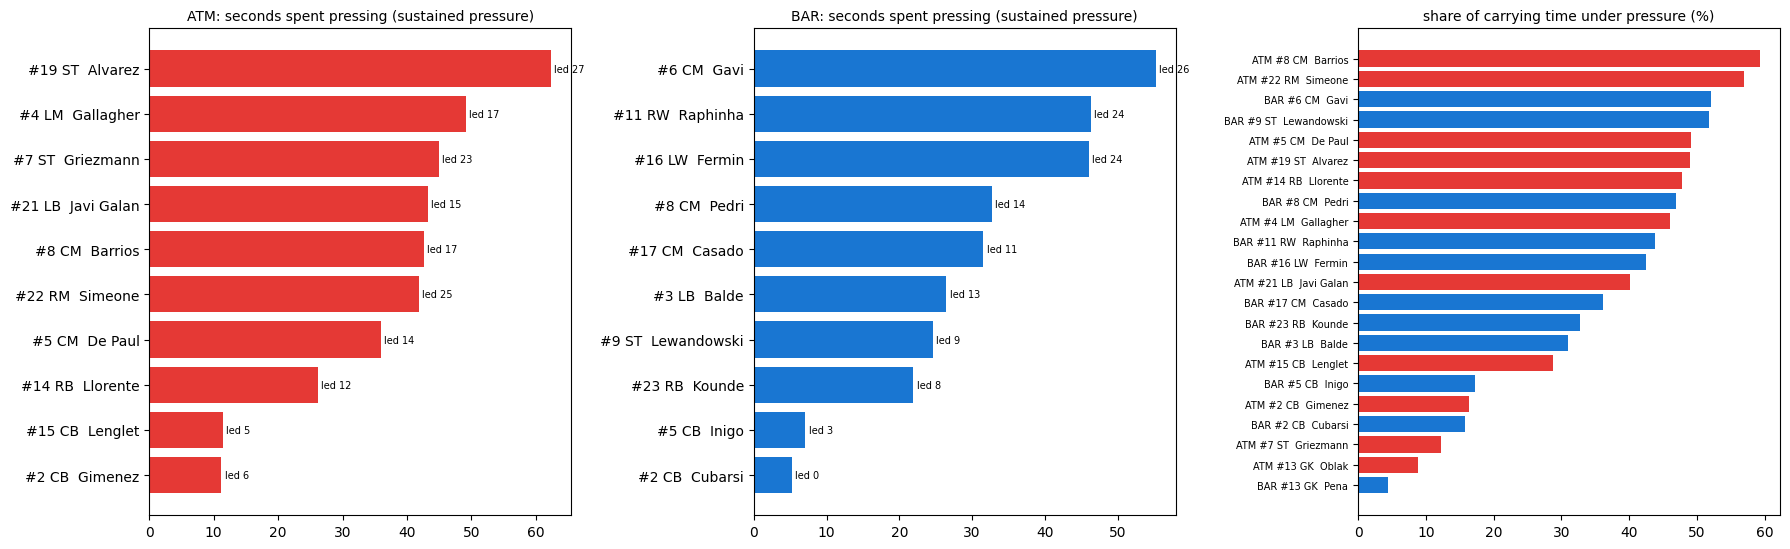


saved 3 tables and 1 figure to C:\Users\user\Desktop\Football_cv_project\football-pipeline (1)\project\new\press\pressure_stats_output


In [7]:
# ================================================================== cell 6: PLAYERS - who does the pressing, and who gets pressed?
# needs cells 1-3 (frames, defenders with roster team / number / position, roster, episodes). A defender "presses" in a frame when the per-defender rule from the
# analysis notebook holds (within 5 m of the pressed player and either within 2 m or closing in fast) AND the team is under sustained pressure in that frame.
MIN_JOIN_FRAMES = 10          # a defender "joins" an episode if he presses for at least this many frames (0.4 s)
rn = roster.set_index("track_id")

dd = defenders.merge(frames[["frame_idx", "def_team", "poss_team", "under_pressure", "x_att"]], on="frame_idx", how="inner")
dd["press_sust"] = dd.is_press & dd.under_pressure
dd["press_height_m"] = PITCH_LENGTH - dd["x_att"]
dd["rank"] = dd.groupby("frame_idx")["dist"].rank(method="first")
dd["nearest"] = dd["rank"] == 1

# ------------------------------------------------------------------ episode membership: which defender led / started / joined each pressure episode
episodes = episodes.reset_index(drop=True); episodes["ep_id"] = episodes.index
ep_map = {}
for r in episodes.itertuples():
    for f in range(r.start_frame, r.end_frame + 1):
        ep_map[f] = r.ep_id
dd["ep_id"] = dd.frame_idx.map(ep_map)
pe = (dd[dd.ep_id.notna() & dd.is_press].groupby(["ep_id", "track_id"])
      .agg(n=("frame_idx", "size"), first=("frame_idx", "min"), mean_dist=("dist", "mean")).reset_index())
pe = pe.merge(episodes[["ep_id", "press_team"]], on="ep_id")
main = pe.sort_values(["ep_id", "n", "mean_dist"], ascending=[True, False, True]).groupby("ep_id").head(1)       # most pressing frames = leads the press
first = pe.sort_values(["ep_id", "first", "mean_dist"]).groupby("ep_id").head(1)                                  # first defender to press
joined = pe[pe.n >= MIN_JOIN_FRAMES]
onset = pe.merge(dd[["frame_idx", "track_id", "closing"]], left_on=["first", "track_id"], right_on=["frame_idx", "track_id"], how="left")
n_ep = episodes.groupby("press_team").size()

# ------------------------------------------------------------------ A) per player
team_def_frames = frames.groupby("def_team").size()
rows = []
for tid, g in dd.groupby("track_id"):
    t = int(rn.loc[tid, "team"]); ps = g[g.press_sust]
    rows.append({"team": tn(t), "number": rn.loc[tid, "number"], "name": rn.loc[tid, "name"], "position": rn.loc[tid, "position"], "track_id": tid,
                 "press seconds": round(len(ps) / FPS, 1),
                 "episodes joined": int((joined.track_id == tid).sum()), "episodes led": int((main.track_id == tid).sum()), "episodes started": int((first.track_id == tid).sum()),
                 "mean distance when pressing m": round(ps.dist.mean(), 2) if len(ps) else np.nan,
                 "closing speed at onset m/s": round(onset.loc[onset.track_id == tid, "closing"].mean(), 2),
                 "nearest defender % of defending time": round(g.nearest.sum() / team_def_frames[t] * 100, 1),
                 "mean pressing height m": round(ps.press_height_m.mean(), 1) if len(ps) else np.nan})
tbl_players = pd.DataFrame(rows)
tot_press = tbl_players.groupby("team")["press seconds"].transform("sum")
tbl_players["share of team press seconds %"] = (tbl_players["press seconds"] / tot_press * 100).round(1)
team_id = {v: k for k, v in TEAM_NAMES.items()}
tbl_players["share of episodes led %"] = [round(l / n_ep[team_id[tm]] * 100, 1) for l, tm in zip(tbl_players["episodes led"], tbl_players.team)]
tbl_players = tbl_players.sort_values(["team", "press seconds"], ascending=[True, False])
show = ["team", "number", "name", "position", "press seconds", "share of team press seconds %", "episodes joined", "episodes led", "share of episodes led %",
        "episodes started", "mean distance when pressing m", "closing speed at onset m/s", "nearest defender % of defending time", "mean pressing height m"]
for t in (0, 1):
    print(f"{tn(t)} PLAYERS WHEN DEFENDING (sorted by pressing seconds; {n_ep[t]} pressure episodes)")
    print(tbl_players[tbl_players.team == tn(t)][show[1:]].to_string(index=False)); print()

# ------------------------------------------------------------------ B) by position
by_pos = (tbl_players.groupby(["team", "position"]).agg(players=("track_id", "size"), press_seconds=("press seconds", "sum"), episodes_led=("episodes led", "sum"),
                                                          episodes_joined=("episodes joined", "sum"), mean_height_m=("mean pressing height m", "mean")).reset_index())
by_pos["share of team press seconds %"] = (by_pos.press_seconds / by_pos.groupby("team").press_seconds.transform("sum") * 100).round(1)
by_pos["press seconds per player"] = (by_pos.press_seconds / by_pos.players).round(1)
by_pos = by_pos.sort_values(["team", "press_seconds"], ascending=[True, False]).round(1)
print("PRESSING BY POSITION"); print(by_pos.to_string(index=False))

# ------------------------------------------------------------------ C) who gets pressed: the ball carriers
car = frames[frames.src == "carrier"].dropna(subset=["carrier_track_id"]).copy(); car["carrier_track_id"] = car.carrier_track_id.astype(int)
rows = []
for tid, g in car.groupby("carrier_track_id"):
    if tid not in rn.index or len(g) < 250:
        continue                                                          # fewer than 10 s as the carrier: not reported
    up = g[g.under_pressure.astype(bool)]
    row = {"team": tn(rn.loc[tid, "team"]), "number": rn.loc[tid, "number"], "name": rn.loc[tid, "name"], "position": rn.loc[tid, "position"],
           "seconds as carrier": round(len(g) / FPS), "% of it under pressure": round(len(up) / len(g) * 100, 1),
           "mean pressers when pressed": round(up.n_pressing.mean(), 2) if len(up) else np.nan}
    if "mom" in globals():
        m = mom[mom.carrier_id == tid]
        row.update({"moments": len(m), "pressed moments": int(m.pressed.sum()), "balls lost within 2 s": int(m.loss_next.sum())})
    rows.append(row)
tbl_carriers = pd.DataFrame(rows).sort_values(["team", "% of it under pressure"], ascending=[True, False])
print("\nWHO GETS PRESSED: carriers with at least 10 s on the ball"); print(tbl_carriers.to_string(index=False))

# ------------------------------------------------------------------ figures
fig, ax = plt.subplots(1, 3, figsize=(18, 5.6)); colr = ["#E53935", "#1976D2"]
for i, t in enumerate((0, 1)):
    x = tbl_players[tbl_players.team == tn(t)].sort_values("press seconds")
    lab = [f"#{int(n)} {p}  {nm}" for n, p, nm in zip(x.number, x.position, x.name)]
    ax[i].barh(lab, x["press seconds"], color=colr[i]); ax[i].set_title(f"{tn(t)}: seconds spent pressing (sustained pressure)", fontsize=10)
    for y, (v, led) in enumerate(zip(x["press seconds"], x["episodes led"])):
        ax[i].text(v + 0.5, y, f"led {led}", va="center", fontsize=7)
c = tbl_carriers.sort_values("% of it under pressure")
ax[2].barh([f"{tm} #{int(n)} {p}  {nm}" for tm, n, p, nm in zip(c.team, c.number, c.position, c.name)], c["% of it under pressure"], color=[colr[0] if t == tn(0) else colr[1] for t in c.team])
ax[2].set_title("share of carrying time under pressure (%)", fontsize=10); ax[2].tick_params(axis="y", labelsize=7)
plt.tight_layout(); plt.savefig(OUT_DIR / "fig_6_players.png", dpi=130); plt.show()

tbl_players.to_csv(OUT_DIR / "tbl_players_pressing.csv", index=False); by_pos.to_csv(OUT_DIR / "tbl_pressing_by_position.csv", index=False)
tbl_carriers.to_csv(OUT_DIR / "tbl_players_pressed.csv", index=False)
print("\nsaved 3 tables and 1 figure to", OUT_DIR)

In [8]:
# ================================================================== cell 7: SUMMARY - key facts, JSON for the LLM layer, methods note, Excel workbook, video-check sample
import re, json, datetime

def parse_ci(s):
    """'29.3% (24-34)' or '44.8 (41.6-48.1)' -> (point, low, high)."""
    m = re.match(r"\s*(-?[\d.]+)%?\s*\((-?[\d.]+)\s*(?:-|to)\s*(-?[\d.]+)\)", str(s))
    return tuple(float(x) for x in m.groups()) if m else (np.nan, np.nan, np.nan)

def overlap(a, b):
    return not (a[2] < b[1] or b[2] < a[1])

def jsonable(o):
    if isinstance(o, (np.integer,)): return int(o)
    if isinstance(o, (np.floating,)): return None if np.isnan(o) else float(o)
    if isinstance(o, (np.bool_,)): return bool(o)
    if isinstance(o, (pd.Timestamp,)): return str(o)
    if isinstance(o, float) and np.isnan(o): return None
    return str(o)

def records(df):
    return json.loads(json.dumps(df.reset_index().to_dict(orient="records"), default=jsonable))

A, B = tn(0), tn(1)
def versus(label, ci_a, ci_b, unit="%"):
    """One careful sentence comparing two teams: it only says 'higher' when the 95% intervals do not overlap."""
    (pa, la, ha), (pb, lb, hb) = ci_a, ci_b
    s = f"{label}: {A} {pa:g}{unit} ({la:g}-{ha:g}), {B} {pb:g}{unit} ({lb:g}-{hb:g}); "
    if overlap(ci_a, ci_b):
        return s + "the intervals overlap, so the data do not show a reliable difference."
    return s + f"{A if pa > pb else B} is higher and the intervals do not overlap."

facts = []
try:
    facts.append(versus("success rate of decided build-ups", parse_ci(tbl_buildups.loc[A, "success of decided"]), parse_ci(tbl_buildups.loc[B, "success of decided"])))
    facts.append(versus("time under pressure when the ball is on a carrier", parse_ci(tbl_pressure_faced.loc[A, "... carrier frames only"]), parse_ci(tbl_pressure_faced.loc[B, "... carrier frames only"])))
    facts.append(versus("build-ups pressed at some point", parse_ci(tbl_pressure_buildups.loc[A, "pressed at some point"]), parse_ci(tbl_pressure_buildups.loc[B, "pressed at some point"])))
    facts.append(versus("pressure episodes per 10 min of defending", parse_ci(tbl_pressing.loc[A, "episodes per 10 min"]), parse_ci(tbl_pressing.loc[B, "episodes per 10 min"]), unit=""))
    ha_, hb_ = tbl_pressing.loc[A, "mean pressing height m (from own goal)"], tbl_pressing.loc[B, "mean pressing height m (from own goal)"]
    facts.append(f"mean pressing height (ball distance from the pressing team's own goal when an episode starts): {A} {ha_} m, {B} {hb_} m; "
                 + (f"{A if ha_ > hb_ else B} presses higher up the pitch (a descriptive difference of {abs(ha_ - hb_):.0f} m)." if abs(ha_ - hb_) >= 5 else "the two are similar."))
    la_, lb_ = (parse_ci(tbl_shape.loc[(t, "while pressing"), "last defender, m from own goal"]) for t in (A, B))
    facts.append(versus("last outfield defender's distance from his own goal while the team presses", la_, lb_, unit=" m"))
    facts.append(f"share of pressure episodes that start within {COUNTERPRESS_SEC:.0f} s of losing the ball (counter-press): "
                 f"{A} {tbl_pressing.loc[A, 'counter-press episodes % (<=5 s after losing the ball)']}%, {B} {tbl_pressing.loc[B, 'counter-press episodes % (<=5 s after losing the ball)']}% (descriptive).")
except Exception as e:
    facts.append(f"(some team comparisons could not be generated: {e})")
effect = {}
if "tbl_effect" in globals():
    try:
        r = tbl_effect.loc["BOTH"]
        facts.append(f"losing the ball within 2 s: {r.pressed_loss_pct}% of pressed moments against {r.unpressed_loss_pct}% of unpressed moments, "
                     f"a difference of {r.diff_pp} points (95% interval {r.ci95}).")
        adj = tbl_logit[(tbl_logit.model.str.startswith("B")) & (tbl_logit.variable == "pressed in the last second")]
        if len(adj) and adj.iloc[0]["adjusted effect of pressure, points"] != "":
            facts.append(f"after controlling for team, ball height and carrier share, being pressed is associated with {adj.iloc[0]['adjusted effect of pressure, points']} more points of "
                         "loss probability within 2 s (an association, not proof of cause).")
        effect = dict(simple=records(tbl_effect), by_pressers=records(dose), by_open_lanes=records(lane_tbl), logistic=json.loads(tbl_logit.to_json(orient="records")))
    except Exception as e:
        facts.append(f"(the effect facts could not be generated: {e})")

top_p = {tn(t): records(tbl_players[tbl_players.team == tn(t)].head(5)[["number", "name", "position", "press seconds", "share of team press seconds %", "episodes led", "mean pressing height m"]].set_index("number")) for t in (0, 1)}
top_c = {tn(t): records(tbl_carriers[tbl_carriers.team == tn(t)].head(3)[["number", "name", "position", "seconds as carrier", "% of it under pressure"]].set_index("number")) for t in (0, 1)}

caveats = [
    "First half only, one match; tracking comes from broadcast video, so on average about one outfield player per team is not tracked in a frame: all pressure figures are lower bounds.",
    "About half of the possession frames have no tracked carrier; there the press target is the ball position, and pressure on a loose or airborne ball is less well defined. Carrier-only figures are given where it matters.",
    "Pressure is a geometric proxy (distance and closing speed of defenders); it does not use body orientation or intent. Episodes include sustained single-defender pressure and have not yet been validated against video (see the validation sample).",
    "Player positions are inferred from average locations and checked by hand; they are not official line-up data.",
    "Intervals are 95% intervals from resampling possession spells or build-ups; with about 90 build-ups per team, differences with overlapping intervals should not be presented as real.",
    "The effect estimates are associations (pressed vs not pressed within a build-up), adjusted for a few covariates; they are not causal.",
]
summary = dict(
    generated=datetime.date.today().isoformat(),
    match=dict(half="first half", teams=TEAM_NAMES, attack_direction={tn(k): ("towards +x (left to right)" if v else "towards -x (right to left)") for k, v in ATTACKS_POS_X.items()},
               minutes_with_a_press_target=round(len(frames) / FPS / 60, 1), half_length_min=round(frames.frame_idx.max() / FPS / 60, 1)),
    key_facts=facts,
    build_ups=records(tbl_buildups), pressure_faced_time=records(tbl_pressure_faced), pressure_faced_buildups=records(tbl_pressure_buildups),
    pressing_delivered=records(tbl_pressing), pressing_by_third=json.loads(tbl_press_height.to_json(orient="records")),
    episode_definition_sensitivity=records(tbl_episode_sensitivity),
    where=dict(share_of_pressing_frames=json.loads(tbl_zone_share.to_json(orient="records")), pressing_rate=json.loads(tbl_zone_rate.to_json(orient="records"))),
    defensive_shape=json.loads(tbl_shape.reset_index().to_json(orient="records")),
    effect=effect, top_pressers=top_p, most_pressed_carriers=top_c, caveats=caveats,
    parameters=dict(analysis=P, press_episode=dict(stay_near=EP_STAY_NEAR, bridge_sec=EP_BRIDGE_SEC, min_sec=EP_MIN_SEC), min_coverage=MIN_COVERAGE),
)
with open(OUT_DIR / "pressure_summary.json", "w", encoding="utf-8") as f_:
    json.dump(summary, f_, indent=2, ensure_ascii=False, default=jsonable)

# ------------------------------------------------------------------ methods note for the thesis (parameters filled in from the data)
p_ = lambda k, d="?": P.get(k, d)
methods = f"""# Pressure statistics: how the numbers were produced (generated {datetime.date.today().isoformat()})

**Data.** Player and ball tracking from broadcast video of the first half ({frames.frame_idx.max() / FPS / 60:.1f} min at {FPS} fps), pitch coordinates in metres.
Possession comes from the provided possession flag; a change of possession counts only after a stable hold; stoppages are excluded.

**Build-up.** A build-up starts when a team has the ball in its own or middle third (thirds at {PITCH_LENGTH / 3:.0f} m and {2 * PITCH_LENGTH / 3:.0f} m from its own goal) and ends in
success (ball held in the final third for at least {p_('ENTRY_HOLD_SEC', 0.5)} s), loss (the opponent gets a stable hold) or undecided (out of play, stoppage, untracked gap).

**Pressure on the ball carrier.** For every possession frame the press target is the carrier (else the ball). A defender presses when he is within {p_('PRESS_DIST_M')} m of the target and either within
{p_('PRESS_TIGHT_M')} m or closing in at {p_('CLOSING_SPEED_MPS')} m/s or more (measured over {p_('CLOSING_WINDOW_SEC')} s). The team is "under pressure" when at least one defender presses for {p_('PRESS_SUSTAIN_SEC')} s in a row.

**Pressure episodes.** An episode starts with sustained pressure, continues while a defender is within {p_('NEAR_DIST_M')} m of the pressed player, bridges interruptions of up to {EP_BRIDGE_SEC} s and lasts at least {EP_MIN_SEC} s.
Counts are sensitive to this choice; the sensitivity table shows the alternatives.

**Statistics.** Shares and rates come with 95% intervals from resampling whole possession spells (frame-based figures) or build-ups (effect figures); proportions of build-ups use Wilson intervals.
The effect of pressure is the difference in the chance of losing the ball within 2 s of a moment (one moment per second), pressed vs not pressed in the previous second, plus logistic models adjusted for team, ball height, carrier share and open passing lanes.

**Limits.** """ + " ".join(f"({i + 1}) {c}" for i, c in enumerate(caveats)) + "\n"
(OUT_DIR / "METHODS_pressure_stats.md").write_text(methods, encoding="utf-8")

# ------------------------------------------------------------------ Excel workbook with every table
sheets = {"buildups": tbl_buildups, "pressure_faced_time": tbl_pressure_faced, "pressure_faced_buildups": tbl_pressure_buildups, "pressing_delivered": tbl_pressing,
          "pressing_by_third": tbl_press_height, "episode_sensitivity": tbl_episode_sensitivity, "zone_share": tbl_zone_share, "zone_rate": tbl_zone_rate, "defensive_shape": tbl_shape,
          "players_pressing": tbl_players, "pressing_by_position": by_pos, "players_pressed": tbl_carriers}
if "tbl_effect" in globals():
    sheets.update({"effect_simple": tbl_effect, "effect_logit": tbl_logit})
try:
    with pd.ExcelWriter(OUT_DIR / "pressure_stats_tables.xlsx") as xw:
        for name, tb in sheets.items():
            tb.to_excel(xw, sheet_name=name[:31], index=isinstance(tb.index, pd.MultiIndex) or tb.index.name is not None)
    xl = "pressure_stats_tables.xlsx"
except Exception as e:
    xl = f"(Excel workbook skipped: {e}; the CSV files are enough)"

# ------------------------------------------------------------------ sample to check the pressure episodes against the video
rng = np.random.default_rng(42)
pos_s = pd.concat([g.sample(min(15, len(g)), random_state=42) for _, g in episodes.groupby("press_team")])
in_ep = np.zeros(int(frames.frame_idx.max()) + 2 * FPS + 1, bool)
for r in episodes.itertuples():
    in_ep[max(0, r.start_frame - FPS): r.end_frame + FPS + 1] = True
cand = frames[(frames.n_near >= 1) & ~in_ep[frames.frame_idx.to_numpy()]]
neg_f = rng.choice(cand.frame_idx.to_numpy(), size=min(30, len(cand)), replace=False) if len(cand) else []
val = pd.concat([
    pd.DataFrame(dict(label_source="detected_episode", press_team=pos_s.press_team.map(tn), start_time=pos_s.start_frame.map(mmss), start_frame=pos_s.start_frame, end_frame=pos_s.end_frame)),
    pd.DataFrame(dict(label_source="hard_negative", press_team=[tn(int(frames.loc[frames.frame_idx == f, "def_team"].iloc[0])) for f in neg_f], start_time=[mmss(f) for f in neg_f],
                      start_frame=neg_f, end_frame=[f + 3 * FPS for f in neg_f]))], ignore_index=True)
val["true_press"] = ""; val = val.sample(frac=1, random_state=1).reset_index(drop=True)
val.to_csv(OUT_DIR / "episode_validation_sample.csv", index=False)

# ------------------------------------------------------------------ report
print("KEY FACTS (generated from the tables; sentences say 'higher' only when the intervals do not overlap)\n")
for i, s_ in enumerate(facts, 1):
    print(f"{i}. {s_}")
print("\nfiles in", OUT_DIR)
for p in sorted(OUT_DIR.iterdir()):
    print(f"  {p.name:42s} {p.stat().st_size / 1e3:9.1f} KB")
print(f"\nExcel: {xl}\nvalidation sample: {len(val)} rows ({(val.label_source == 'detected_episode').sum()} detected episodes, {(val.label_source == 'hard_negative').sum()} hard negatives); fill 'true_press' with 1 / 0 after watching the video")

KEY FACTS (generated from the tables; sentences say 'higher' only when the intervals do not overlap)

1. success rate of decided build-ups: ATM 20% (12-31), BAR 64.8% (53-75); BAR is higher and the intervals do not overlap.
2. time under pressure when the ball is on a carrier: ATM 35.9% (29-43), BAR 31.8% (28-36); the intervals overlap, so the data do not show a reliable difference.
3. build-ups pressed at some point: ATM 80% (71-87), BAR 65.2% (55-74); the intervals overlap, so the data do not show a reliable difference.
4. pressure episodes per 10 min of defending: ATM 77.7 (69.4-86.5), BAR 92.2 (77-106.6); the intervals overlap, so the data do not show a reliable difference.
5. mean pressing height (ball distance from the pressing team's own goal when an episode starts): ATM 43.6 m, BAR 67.4 m; BAR presses higher up the pitch (a descriptive difference of 24 m).
6. last outfield defender's distance from his own goal while the team presses: ATM 23.6 m (20.7-26.7), BAR 44.8 m (41.6-48.